<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch_06_Further_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## We will work on the MNIST (Yann Le cunn famous paper's dataset)

In [1]:
import torchvision
from torchvision import transforms
import torch
from torch.utils.data import Subset

In [2]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
transform= transforms.Compose([
    transforms.ToTensor()
])
image_path='./'

mnist_dataset= torchvision.datasets.MNIST(
    root=image_path,
    train=True,
    download=True,
    transform=transform
)

#Let's set aside validation data: the first 10000 data points
mnist_valid_dataset= Subset(mnist_dataset,
                            torch.arange(10000))
mnist_train_dataset= Subset(mnist_dataset,
                            torch.arange(10000, len(mnist_dataset)))
mnist_test_dataset= torchvision.datasets.MNIST(
    root= image_path,
    train= False,
    transform= transform,
    download=False
)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.23MB/s]


In [4]:
from torch.utils.data import DataLoader
torch.manual_seed(42)
BATCH_SIZE= 64
train_dl= DataLoader(mnist_train_dataset,
                     batch_size= BATCH_SIZE,
                     shuffle= True)
valid_dl= DataLoader(mnist_valid_dataset,
                     batch_size= BATCH_SIZE,
                     shuffle= False)


In [5]:
# Let's construct a basic 2 blocks CNN
from torch import nn
class CNN_Module(nn.Module):

  def __init__(self, input_shape, output_shape):

    super().__init__()
    self.block_1= nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels= 32,
                  kernel_size= 5,
                  padding= 2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2)

    )
    self.block_2= nn.Sequential(
        nn.Conv2d(in_channels=32,
                  out_channels=64,
                  kernel_size=5,
                  padding=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)

    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= 64*7*7,
                  out_features= 1024),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(1024, output_shape)
    )

  def forward(self, X):
    X=self.block_1(X)
    X=self.block_2(X)
    X=self.classifier(X)
    return X

torch.manual_seed(42)
MNIST_model= CNN_Module(input_shape=1, output_shape= 10).to(device)

In [6]:
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(MNIST_model.parameters(),
                            lr= 0.001)

In [7]:
# Let's set a training function
def train(model,num_epochs, train_dl, valid_dl):

  loss_hist_train= [0]* num_epochs
  acc_hist_train= [0]* num_epochs
  loss_hist_valid= [0]* num_epochs
  acc_hist_valid= [0]* num_epochs

  for epoch in range(num_epochs):

    model.train()
    for X_batch, y_batch in train_dl:
      X_batch= X_batch.to(device)
      y_batch= y_batch.to(device)
      y_pred= model(X_batch)
      loss= loss_fn(y_pred, y_batch)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      loss_hist_train[epoch] += loss.item()*y_batch.size(0)
      is_correct= (torch.argmax(y_pred, dim=1)== y_batch).float()
      acc_hist_train[epoch] += is_correct.sum().item()
    loss_hist_train[epoch] /= len(train_dl.dataset)
    acc_hist_train[epoch] /= len(train_dl.dataset)

    model.eval()
    with torch.inference_mode():
      for X_batch, y_batch in valid_dl:
        X_batch= X_batch.to(device)
        y_batch= y_batch.to(device)
        y_pred= model(X_batch)
        loss= loss_fn(y_pred, y_batch)
        loss_hist_valid[epoch] += loss.item()*y_batch.size(0)
        is_correct= (torch.argmax(y_pred, dim=1)== y_batch).float()
        acc_hist_valid[epoch] += is_correct.sum().item()
      loss_hist_valid[epoch] /= len(valid_dl.dataset)
      acc_hist_valid[epoch] /= len(valid_dl.dataset)

    print(f"Epoch {epoch+1} accuracy:")
    print(f"Train: {acc_hist_train[epoch]:.4f}, Valid: {acc_hist_valid[epoch]:.4f}")

  return loss_hist_train, loss_hist_valid, acc_hist_train, acc_hist_valid


In [8]:
torch.manual_seed(42)
NUM_EPOCHS= 5
from timeit import default_timer as timer
start_time= timer()
hist= train(MNIST_model, NUM_EPOCHS, train_dl, valid_dl)
end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Epoch 1 accuracy:
Train: 0.9513, Valid: 0.9826
Epoch 2 accuracy:
Train: 0.9848, Valid: 0.9899
Epoch 3 accuracy:
Train: 0.9898, Valid: 0.9889
Epoch 4 accuracy:
Train: 0.9920, Valid: 0.9880
Epoch 5 accuracy:
Train: 0.9930, Valid: 0.9888
Total training time: 57.847 seconds


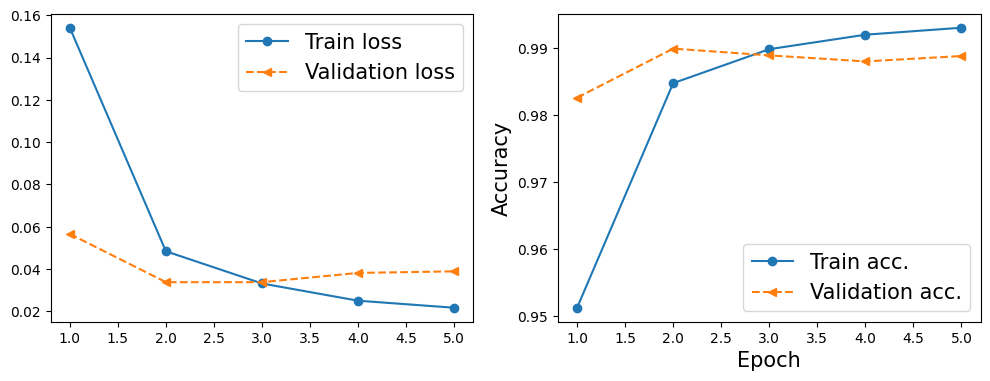

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x_arr = np.arange(len(hist[0])) + 1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<',label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

### Now, Let's evaluate the trained model

In [10]:
def evaluate(model, test_dataset: torchvision.datasets):

  model= model.to(device)

  model.eval()
  with torch.inference_mode():
    pred= model(test_dataset.data.unsqueeze(1).to(device) /255.)
    pred= torch.argmax(pred, dim=1)
    is_correct= (pred== test_dataset.targets.to(device)).float()
    print(f"Test accuracy: {is_correct.mean():.4f}")

evaluate(MNIST_model, mnist_test_dataset)

Test accuracy: 0.9910


## Some visualization:

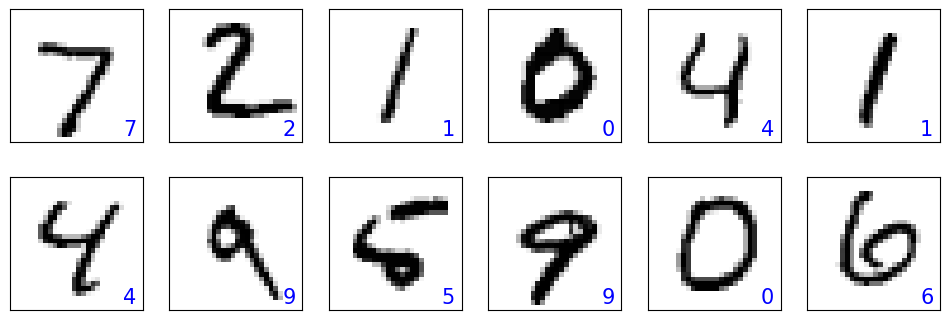

In [11]:
fig = plt.figure(figsize=(12, 4))
for i in range(12):
  ax = fig.add_subplot(2, 6, i+1)
  ax.set_xticks([]); ax.set_yticks([])
  img = mnist_test_dataset[i][0]
  pred = MNIST_model(img.unsqueeze(0).to(device))
  y_pred = torch.argmax(pred)
  ax.imshow(img.squeeze(), cmap='gray_r')
  color="blue" if y_pred == mnist_test_dataset[i][1] else "red"

  ax.text(0.9, 0.1, y_pred.item(),
          size=15, color= color,
          horizontalalignment='center',
          verticalalignment='center',
          transform=ax.transAxes)
plt.show()

### **Let's show an example where the model is making a mistake**

Predicted: 9, Actual: 4


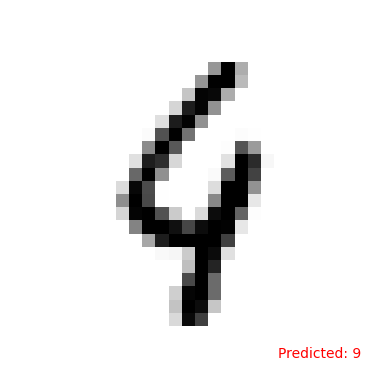

In [12]:
for i in range(len(mnist_test_dataset)):
  img= mnist_test_dataset[i][0]
  pred= MNIST_model(img.unsqueeze(0).to(device))
  y_pred=torch.argmax(pred)
  if y_pred != mnist_test_dataset[i][1]:
    print(f"Predicted: {y_pred}, Actual: {mnist_test_dataset[i][1]}")
    plt.imshow(img.squeeze(), cmap='gray_r')
    plt.axis('off')
    plt.text(
            0.95, 0.05,
            f"Predicted: {y_pred.item()}",
            color="red",
            transform=plt.gca().transAxes,
            ha='right',
            va='bottom',

        )
    plt.show()

    break


# Part 2: Smile Detection with the CelebA dataset

In [13]:
from logging import root
# First, let's setup the dataset
image_path= './'

celeba_train_dataset= torchvision.datasets.CelebA(
    root= image_path, split= "train", target_type= 'attr', download= True
)

celeba_valid_dataset= torchvision.datasets.CelebA(
    root= image_path, split= "valid", target_type= 'attr', download= True
)
celeba_test_dataset= torchvision.datasets.CelebA(
    root= image_path, split= "test", target_type= 'attr', download= True
)


Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=4e0b6efc-f54e-438b-8d7e-cc518e4b333a
To: /content/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:33<00:00, 43.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 51.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 48.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 23.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/celeba/list_landmarks_align_celeba.txt
100

In [15]:
len(celeba_train_dataset), len(celeba_valid_dataset), len(celeba_test_dataset)

(162770, 19867, 19962)

### Let's visualize diffferent techniques of data augmentation

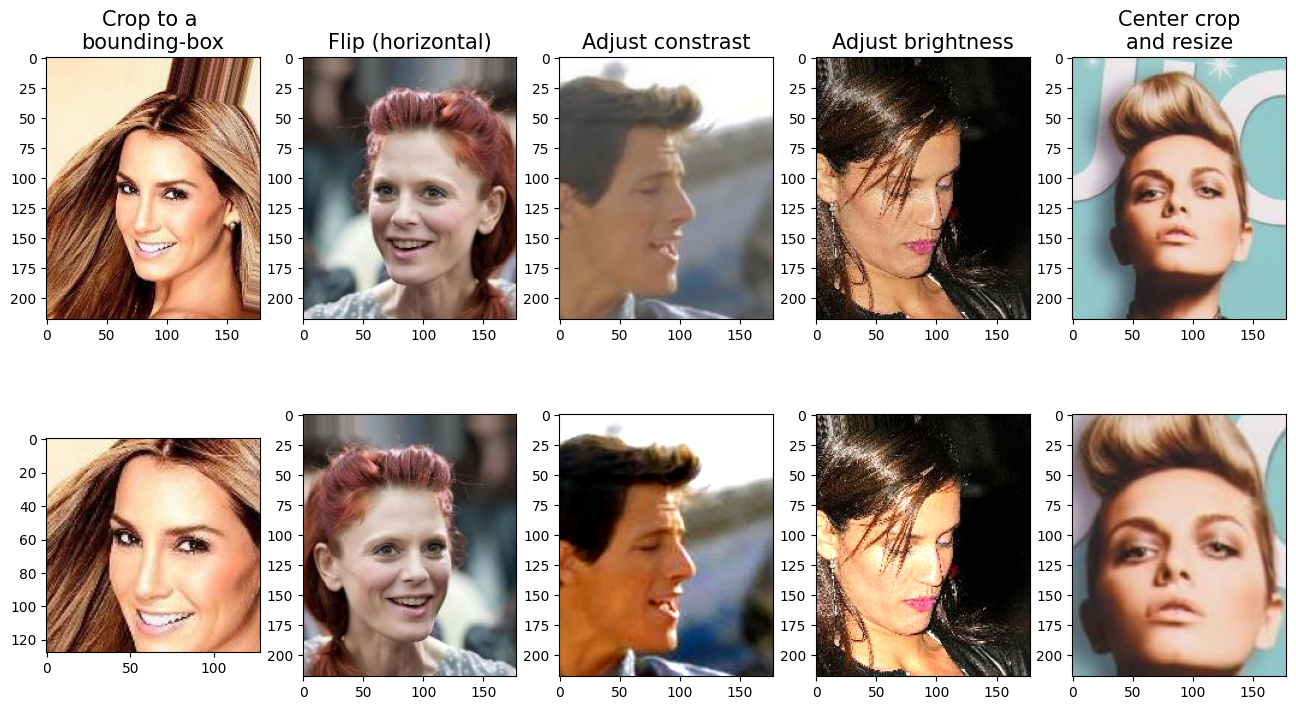

In [18]:
fig = plt.figure(figsize=(16, 8.5))

# Column 1: cropping to a bounding-box
ax = fig.add_subplot(2, 5, 1)
img, attr = celeba_train_dataset[0]
ax.set_title('Crop to a \nbounding-box', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 6)
img_cropped = transforms.functional.crop(img, 50, 20, 128, 128)
ax.imshow(img_cropped)

# Column 2: flipping (horizontally)
ax = fig.add_subplot(2, 5, 2)
img, attr = celeba_train_dataset[1]
ax.set_title('Flip (horizontal)', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 7)
img_flipped = transforms.functional.hflip(img)
ax.imshow(img_flipped)

# Column 3: adjust contrast
ax = fig.add_subplot(2, 5, 3)
img, attr = celeba_train_dataset[2]
ax.set_title('Adjust constrast', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 8)
img_adj_contrast = transforms.functional.adjust_contrast(img, contrast_factor=2)
ax.imshow(img_adj_contrast)

# Column 4: adjust brightness
ax = fig.add_subplot(2, 5, 4)
img, attr = celeba_train_dataset[3]
ax.set_title('Adjust brightness', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 9)
img_adj_brightness = transforms.functional.adjust_brightness(img, brightness_factor=1.3)
ax.imshow(img_adj_brightness)

# Column 5: cropping from image center
ax = fig.add_subplot(2, 5, 5)
img, attr = celeba_train_dataset[4]
ax.set_title('Center crop\nand resize', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 10)
img_center_crop = transforms.functional.center_crop(img, [0.7*218, 0.7*178])
img_resized = transforms.functional.resize(img_center_crop, size=(218, 178))
ax.imshow(img_resized)
plt.show()